# 00 — Data Exploration

Sanity check the XDF before any model work. Mirrors the class-distribution diagnostic already built into `eeg_online_classifier.py --xdf` so the notebook numbers and the online numbers must match.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import matplotlib.pyplot as plt
import pyxdf

from utils.data import load_xdf_epochs, ALL_MARKERS, SRATE_DEFAULT, CHANNELS_DEFAULT
from utils.plot import plot_psd, plot_erp

XDF_PATH = '../visionpro-ml.xdf'

Matplotlib is building the font cache; this may take a moment.


## Raw marker distribution

Should match `python eeg_online_classifier.py --xdf ../visionpro-ml.xdf`.

In [2]:
streams, _ = pyxdf.load_xdf(XDF_PATH)
eeg_stream = next(s for s in streams if s['info']['type'][0] == 'EEG')
mk_stream  = next(s for s in streams if s['info']['type'][0] == 'Markers')

mk_values = [int(v[0]) for v in mk_stream['time_series']]
print(f"Recording length : {eeg_stream['time_stamps'][-1] - eeg_stream['time_stamps'][0]:.1f} s")
print(f"Channels in file : {np.array(eeg_stream['time_series']).shape[1]}")
print(f"Markers in file  : {len(mk_values)}\n")
for m, name in ALL_MARKERS.items():
    print(f"  {name:5s} (marker {m}): {mk_values.count(m)}")

Recording length : 741.0 s
Channels in file : 8
Markers in file  : 271

  left  (marker 769): 30
  right (marker 770): 30
  both  (marker 773): 30


## Preprocessed epochs

In [3]:
X, y, classes = load_xdf_epochs(XDF_PATH)
print('X:', X.shape, ' y:', y.shape, ' classes:', classes)
for i, name in classes.items():
    print(f'  {name:5s}: {int((y == i).sum())} trials')

X: (90, 4, 625)  y: (90,)  classes: {0: 'left', 1: 'right', 2: 'both'}
  left : 30 trials
  right: 30 trials
  both : 30 trials


## Per-channel PSD — post-preprocessing

After the 8–30 Hz bandpass the PSD should peak in mu (8–12 Hz) and taper by 30 Hz. A channel still showing broadband content or a large DC offset is a red flag.

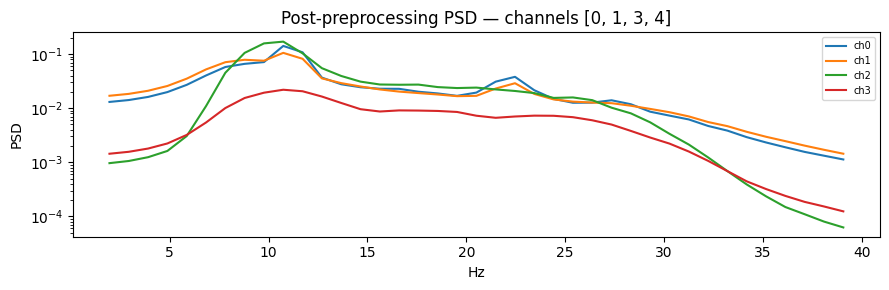

In [4]:
fig, ax = plt.subplots(figsize=(9, 3))
plot_psd(X, srate=SRATE_DEFAULT, band=(1, 40), ax=ax)
ax.set_title(f'Post-preprocessing PSD — channels {CHANNELS_DEFAULT}')
plt.tight_layout(); plt.show()

## Class-conditional ERP

For motor imagery we expect ERD in the mu band, not large ERPs. A flat average is actually normal — this is just a sanity plot that classes aren't identical.

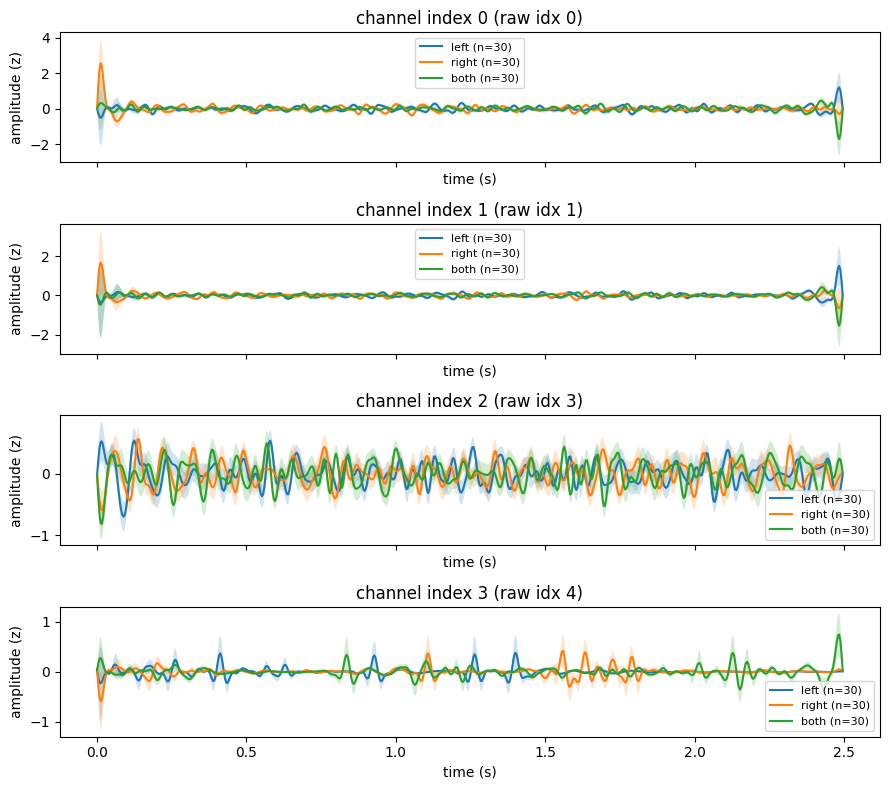

In [5]:
fig, axes = plt.subplots(X.shape[1], 1, figsize=(9, 2 * X.shape[1]), sharex=True)
for ch, ax in enumerate(axes):
    plot_erp(X, y, classes, srate=SRATE_DEFAULT, channel=ch, ax=ax)
    ax.set_title(f'channel index {ch} (raw idx {CHANNELS_DEFAULT[ch]})')
plt.tight_layout(); plt.show()

## Take-aways for modelling

- **Trials / class**: printed above — anything below ~25 per class will hurt deep models.
- **PSD shape**: dominant mu peak is what CSP / Riemannian will exploit.
- **Channel health**: all 4 selected channels should look comparable; if one dominates the PSD by ×10+ it's saturated and should be dropped.